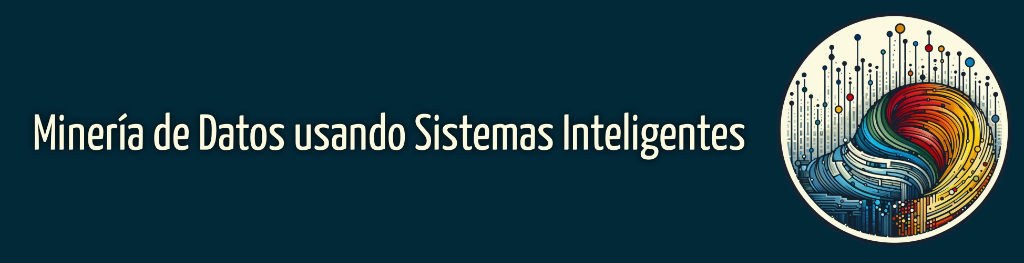



# PRACTICA 1 - PREPROCESAMIENTO DE LOS DATOS

**Ejercicio a entregar: 4. Deberá respetarse el formato de tabla indicado para la resolución.**

***Material de Lectura: Capítulo 4 del Libro Introducción a la Minería de Datos de Hernández Orallo***


En esta práctica el objetivo es aprender las herramientas básicas del ecosistema Python, incluyendo Numpy, Pandas y Seaborn. Para aprender sobre estos 4 temas, hemos preparado algunos cuadernos numerados P0.1, P0.2,... que te guían en un recorrido rápido por el lenguaje y las APIs.

Te recomendamos revisar esos cuadernos rápidamente, y luego aplicar lo visto para resolver los ejercicios de esta práctica.

In [13]:
#HELPER
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


base_url = "https://raw.githubusercontent.com/midusi/learning-datasets/refs/heads/main/"


## 1. Automóviles

Analice la información del archivo **automobile.csv** cuyo contenido se encuentra descripto en "automobile_names.txt"


In [14]:
#HELPER
df_autos = pd.read_csv(base_url + "automobile.csv")

In [18]:
df_autos.head()

,Normalized-losses,Make,Fuel-type,Aspiration,Num-of-doors,Body-style,Drive-wheels,Engine-location,Wheel-base,Length,...,Fuel-system,Bore,Stroke,Compression-ratio,Horsepower,Peak-rpm,City-mpg,Highway-mpg,Price,Symboling
0,168.0,toyota,gas,std,two,sedan,rwd,front,94.5,168.7,...,2bbl,3.19,3.03,9.0,70.0,4800.0,29,34,8058.0,1
1,113.0,mazda,gas,std,four,sedan,fwd,front,93.1,166.8,...,2bbl,3.08,3.15,9.0,68.0,5000.0,31,38,7395.0,1
2,87.0,toyota,gas,std,two,hatchback,fwd,front,95.7,158.7,...,2bbl,3.05,3.03,9.0,62.0,4800.0,35,39,5348.0,1
3,125.0,mitsubishi,gas,std,four,sedan,fwd,front,96.3,172.4,...,2bbl,3.35,3.46,8.5,88.0,5000.0,25,32,6989.0,1
4,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,157.3,...,mpfi,3.03,3.39,7.6,102.0,5500.0,24,30,8558.0,1


In [31]:
df_autos.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Normalized-losses   164 non-null    float64
 1    Make               205 non-null    str    
 2    Fuel-type          205 non-null    str    
 3    Aspiration         205 non-null    str    
 4    Num-of-doors       203 non-null    str    
 5    Body-style         205 non-null    str    
 6    Drive-wheels       205 non-null    str    
 7    Engine-location    205 non-null    str    
 8    Wheel-base         205 non-null    float64
 9    Length             205 non-null    float64
 10   Width              205 non-null    float64
 11   Height             205 non-null    float64
 12   Curb-weight        205 non-null    int64  
 13   Engine-type        205 non-null    str    
 14   Num-of-cylinders   205 non-null    str    
 15   Engine-size        205 non-null    int64  
 16   Fuel-system       


a.  Indique qué tipo de gráfica puede construir con los atributos. Ejemplifique cada caso.

b.  Utilizando distintas representaciones gráficas, describa la distribución de los atributos, e indique si observa relaciones entre los mismos.


### Ejercicio 1, a) 

Las gráficas conocidas hasta este momento son:

- Diagrama de Caja  
  El diagrama de caja (o boxplot) es útil para visualizar rápidamente la distribución, dispersión, simetría y mediana de conjuntos de datos numéricos. Permite identificar valores atípicos (outliers) y comparar grupos de datos entre sí. Como ejemplo, podemos poner la columna precio en donde a priori podemos esperar que muchos autos esten en un rango de la media y que existan valores atípicos para los vehiculos de alta gama


- Histogramas  
  Un histograma sirve para visualizar la distribución, frecuencia y variabilidad de un conjunto de datos numéricos continuos, agrupándolos en intervalos.


- Diagrama de Dispersión
  El diagrama de dispersión (o scatter plot) sirve para analizar la relación entre dos variables numéricas. Su función es la representación de un conjunto de datos en un sistema de coordenadas cartesianas para determinar el grado de correlación entre una variable independiente ($X$) y una variable dependiente ($Y$).

### Ejercicio 1, b) 

<Axes: xlabel=' Price'>

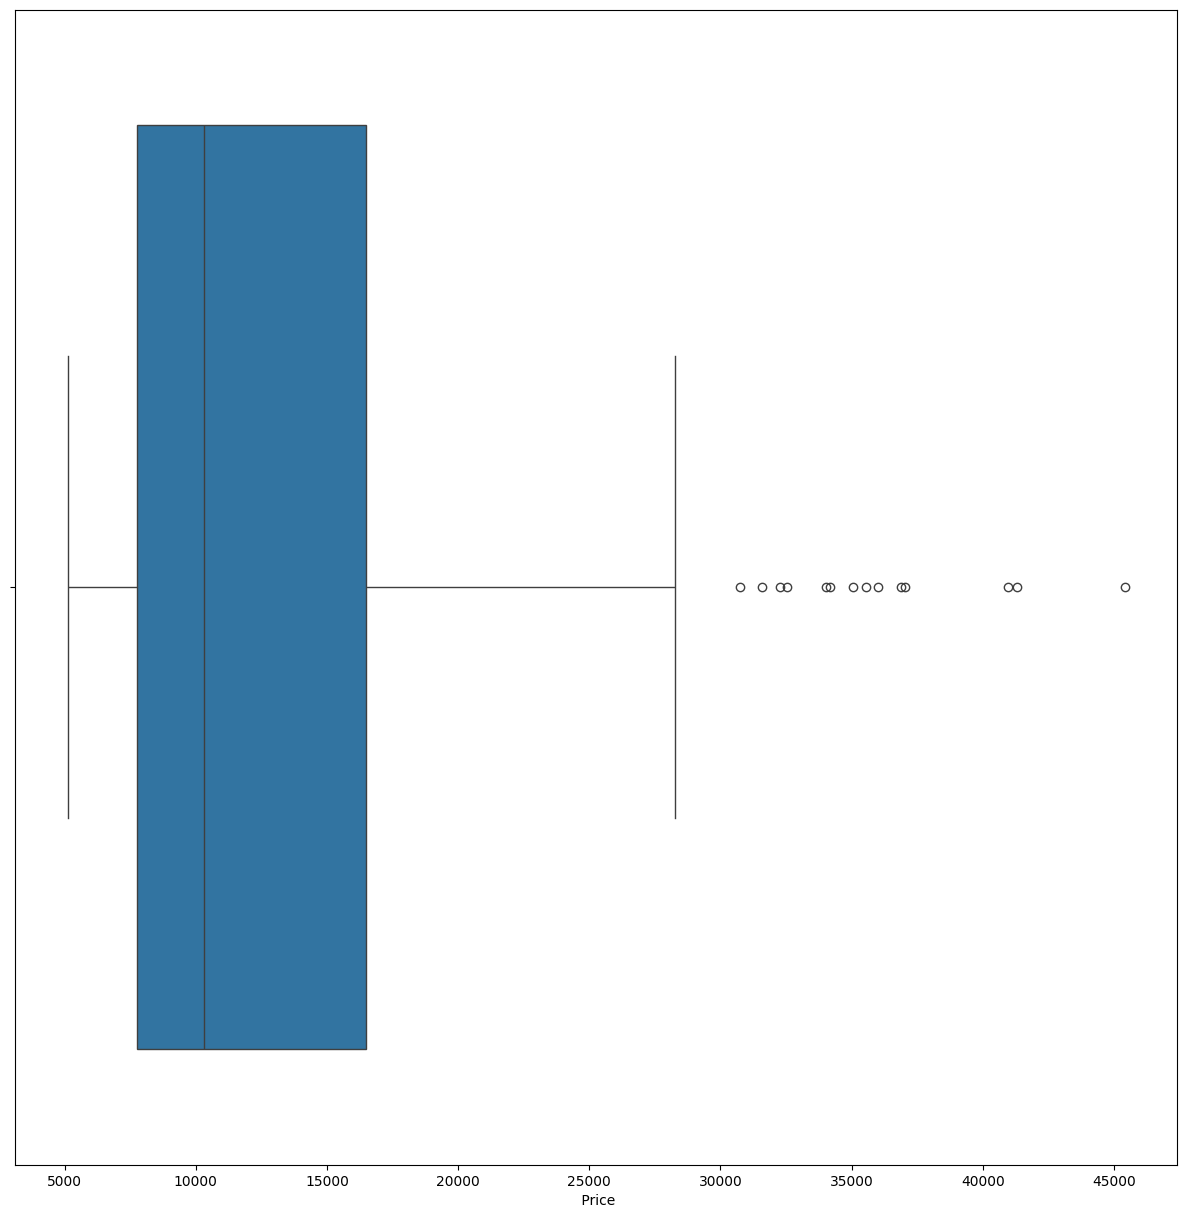

In [54]:
plt.figure(figsize=(15, 15))
sns.boxplot(x=' Price', data=df_autos)

<Axes: xlabel=' Price', ylabel='Count'>

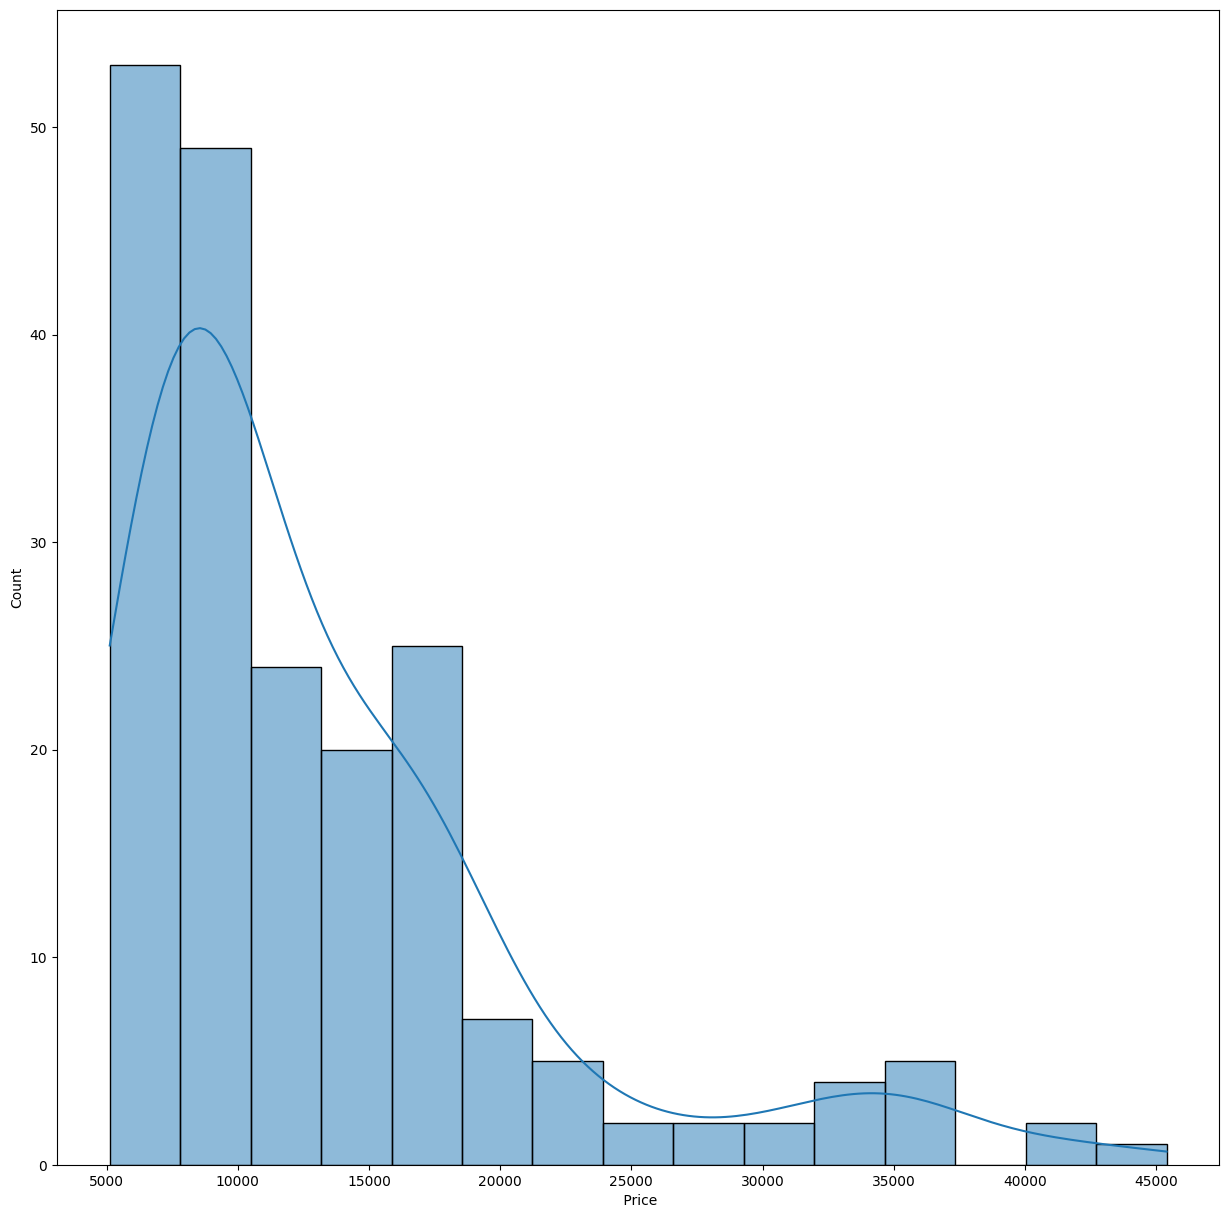

In [53]:
plt.figure(figsize=(15, 15))
sns.histplot(df_autos[' Price'], kde=True, bins=15)

<Axes: xlabel=' Horsepower', ylabel=' City-mpg'>

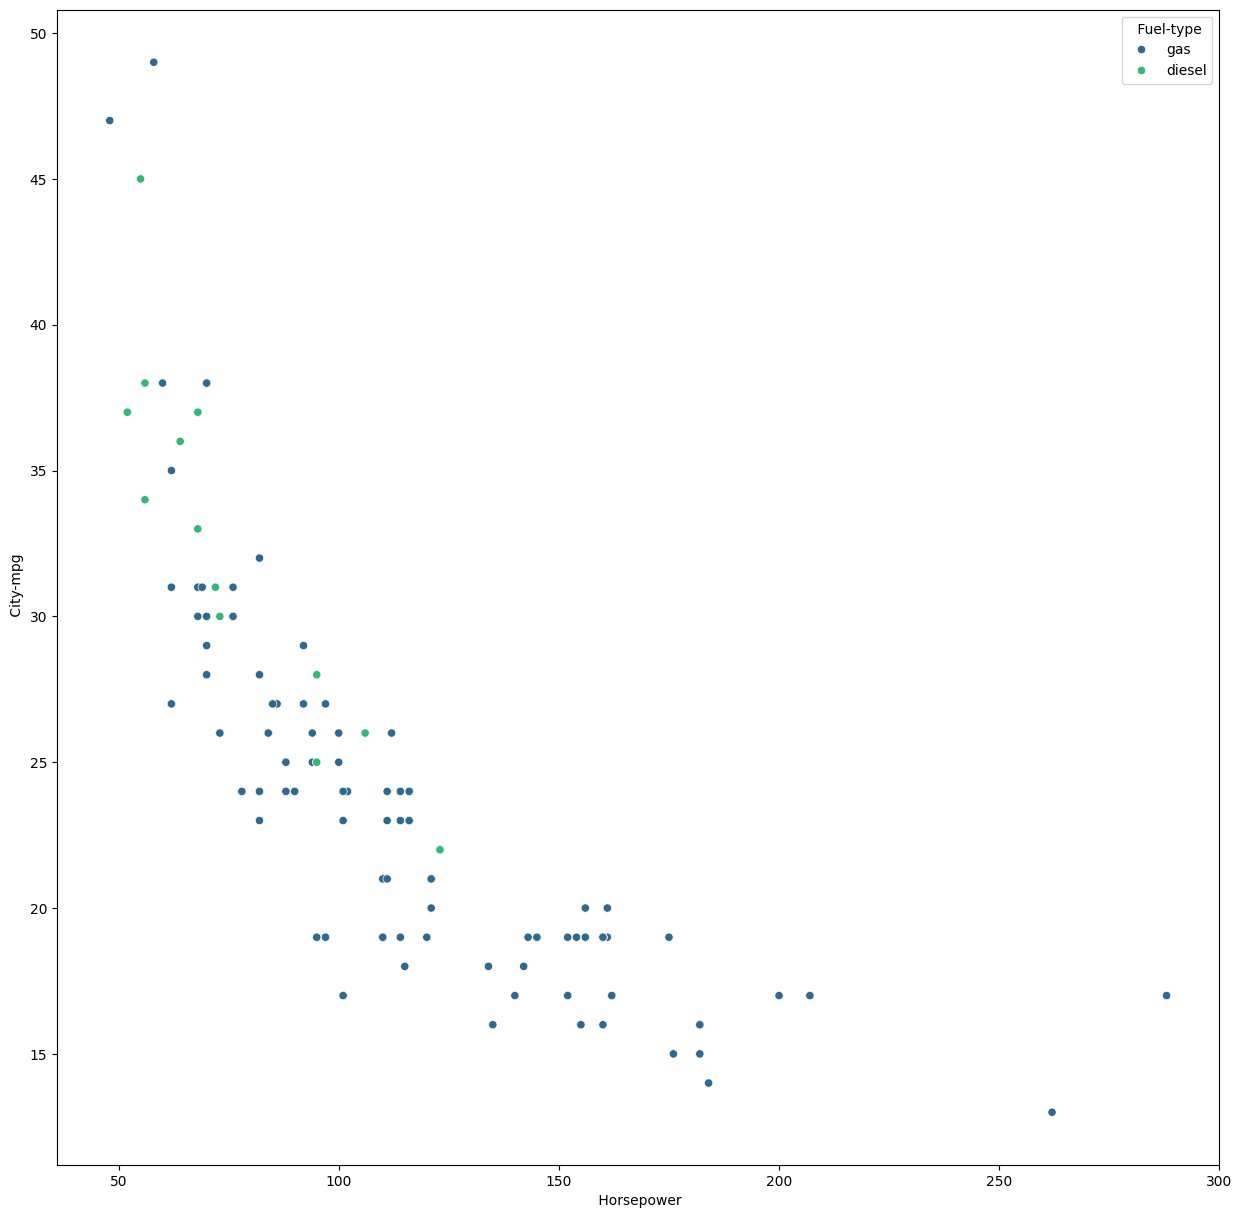

In [45]:
plt.figure(figsize=(15, 15))
sns.scatterplot(data=df_autos, x=' Horsepower', y=' City-mpg', hue=' Fuel-type', palette='viridis')


c.  La Minería de Datos permite extraer dos tipos de conocimiento: descriptivo y predictivo. Ejemplifíquelos para el caso de los autos.

d.  Calcule el coeficiente de correlación lineal entre los atributos numéricos. Relacione los valores obtenidos con los diagramas de dispersión de cada par de atributos.

<Axes: >

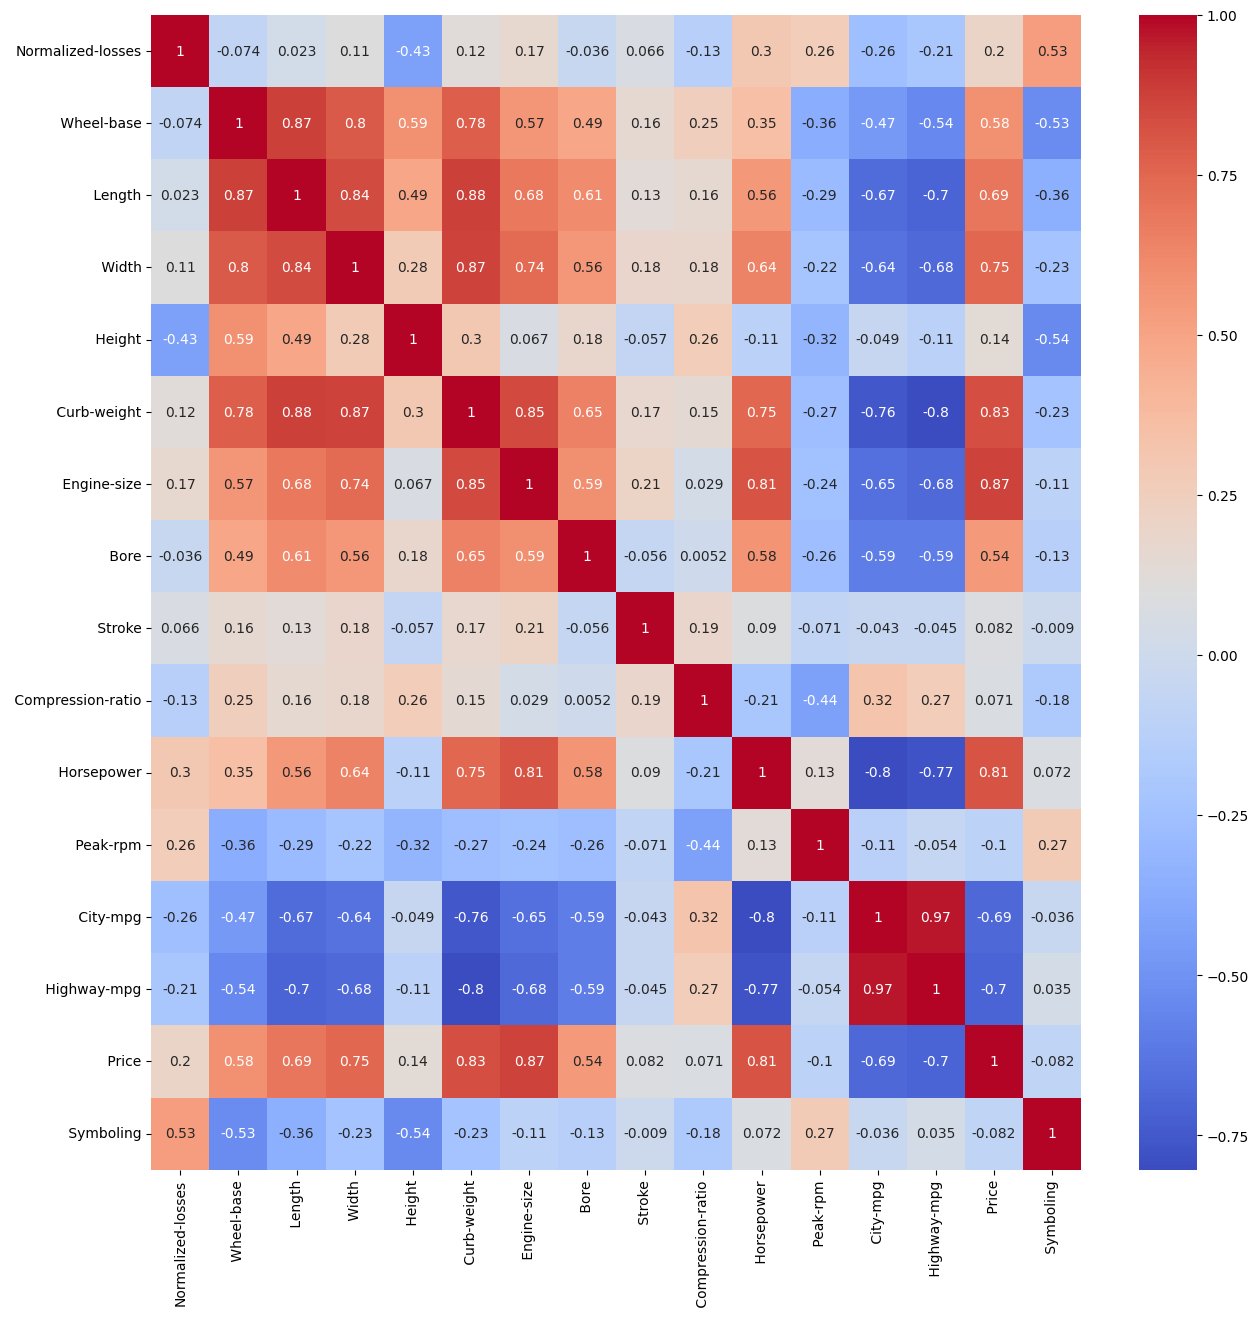

In [52]:
plt.figure(figsize=(15, 15))
sns.heatmap(df_autos.corr(numeric_only=True),annot=True,cmap='coolwarm')

# 2. Bicicletas

En el siguiente link encontrará información referida al uso de bicicletas que el Gobierno de la Ciudad de Buenos Aires pone a disposición de la población en forma gratuita como medio de transporte: [https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/juqdkmgo-227-resource](https://data.buenosaires.gob.ar/dataset/bicicletas-publicas/resource/juqdkmgo-227-resource)

Estas bicicletas están ubicadas en distintos puntos de la ciudad y se encuentran disponibles las 24 horas del día durante todo el año. En el archivo encontrará información referida a las estaciones de origen y destino, la hora de partida y la duración de los viajes realizados por las bicicletas durante el año 2016.

In [64]:
#HELPER
def load_bicicletas():
    import requests
    import zipfile
    import io
    r = requests.get(base_url + "recorridos-realizados-2016.zip")
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        return pd.read_csv(z.open("recorridos-realizados-2016.csv"), dtype={'fecha_destino_recorrido': str})
df_bicicletas = load_bicicletas()

In [92]:
df_bicicletas.info()

<class 'pandas.DataFrame'>
RangeIndex: 596807 entries, 0 to 596806
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   periodo                     596807 non-null  int64  
 1   genero_usuario              596807 non-null  str    
 2   fecha_origen_recorrido      596807 non-null  str    
 3   id_estacion_origen          596807 non-null  int64  
 4   nombre_estacion_origen      596807 non-null  str    
 5   long_estacion_origen        596807 non-null  float64
 6   lat_estacion_origen         596807 non-null  float64
 7   domicilio_estacion_origen   596807 non-null  str    
 8   duracion_recorrido          596807 non-null  str    
 9   fecha_destino_recorrido     503252 non-null  str    
 10  id_estacion_destino         596807 non-null  int64  
 11  nombre_estacion_destino     596807 non-null  str    
 12  long_estacion_destino       596807 non-null  float64
 13  lat_estacion_destino     

a.  A partir del atributo FECHA_ORIGEN_RECORRIDO genere un atributo nuevo que contenga únicamente el horario en el cual la bicicleta fue retirada. Para ello puede obtener el substring que contiene la hora con las funciones de texto del atributo [str](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.html) de la columna, y luego convertir ese substring a un número entero. También puede utilizar la función [to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) convertir el string a un tipo date, y luego utilizar [dt.hour](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.hour.html) para obtener la hora.

In [97]:
df_bicicletas_horario['timespamp'] = pd.to_datetime(df_bicicletas['fecha_origen_recorrido'])
df_bicicletas_horario['hour'] = df_bicicletas_horario['timespamp'].dt.hour 
df_bicicletas_horario['hour']

0          2
1          8
2         15
3         15
4         15
          ..
596802    23
596803    23
596804    23
596805    23
596806    23
Name: hour, Length: 596807, dtype: int32

b.  Genere un histograma donde cada hora represente una barra. Informe si hay horarios inusuales de retiro de bicicletas. Justifique su respuesta utilizando la frecuencia relativa de cada hora para decidir qué es un horario inusual (datos) y en qué horas tradicionalmente circula la gente por una ciudad (su conocimiento sobre el dominio )


<Axes: xlabel='hour', ylabel='Count'>

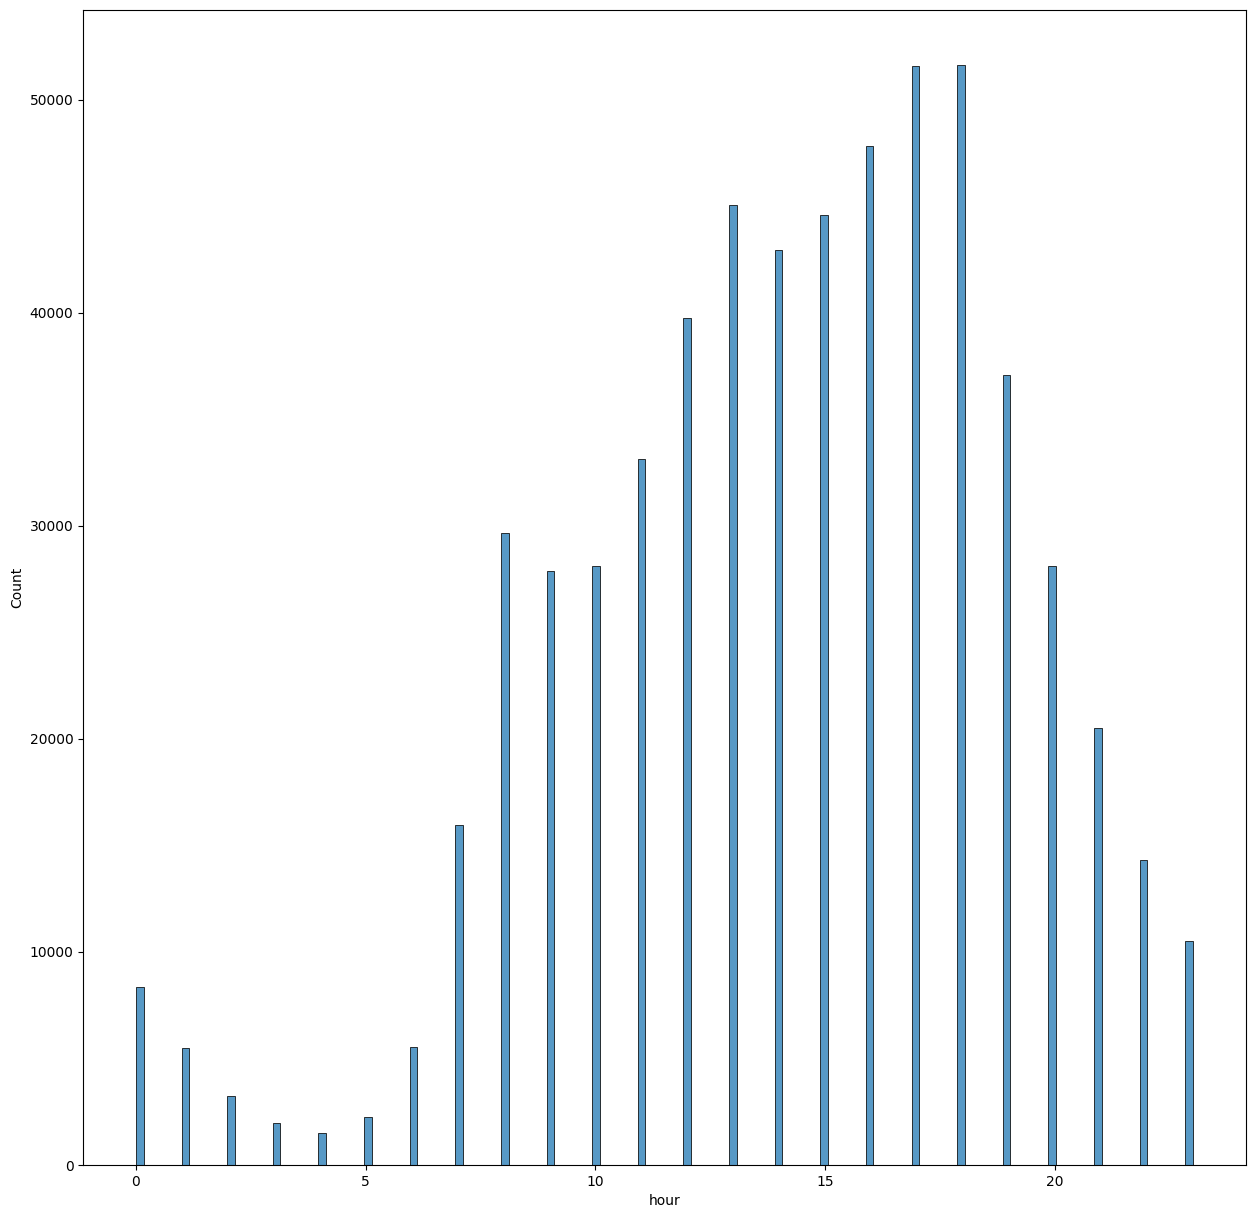

In [102]:
plt.figure(figsize=(15, 15))
sns.histplot(df_bicicletas_horario['hour'], kde=False) #, bins=15)

c.  Discretice por rango el atributo generado en a) utilizando 4 intervalos (función [cut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html)). El resultado ¿es el mismo? ¿por qué?

# 3. Estudiantes

El archivo ***estudiantes.csv*** contiene información de alumnos de dos colegios secundarios de Portugal relevada para analizar la adicción al alcohol en el nivel secundario y la forma en que éste afecta a los estudiantes tanto en sus relaciones como en sus estudios.


| Atributo | Descripción |
| :--- | :--- |
| **escuela** | "GP" - Gabriel Pereira o "MS" - Mousinho da Silveira |
| **sexo** | F (Femenino) o M (Masculino) |
| **edad** | Valor numérico entre 15 y 22 |
| **ambito** | "Rural" o "Urbano" |
| **grupo_familiar** | Tamaño del grupo familiar (<=3 o >3 integrantes) |
| **estado_padres** | Si viven "juntos" o "separados" |
| **educ_madre** | Nivel educativo de la madre |
| **educ_padre** | Nivel educativo del padre |
| **trabajo_madre** | Tipo de trabajo de la madre |
| **trabajo_padre** | Tipo de trabajo del padre |
| **razon_escuela** | Motivos por los cuales eligió la escuela |
| **tutor** | Indica quién es el tutor legal del estudiante |
| **duracion_viaje** | Tiempo que tarda en llegar a la escuela |
| **tiempo_estudio** | Cantidad de horas que estudia por semana |
| **asignaturas_perdidas** | Cantidad de materias desaprobadas (N si 0 <= N < 3, sino 3) |
| **becas** | Si tiene beca de estudios |
| **apoyo_familiar** | Si su familia lo ayuda económicamente |
| **clases_particulares** | Si toma clases particulares pagas |
| **act_extracurriculares** | Si realiza actividades extracurriculares |
| **fue_guarderia** | Si fue a guardería |
| **quiere_educ_superior** | Si piensa ir a la universidad |
| **internet_casa** | Si posee internet en su casa |
| **en_pareja** | Si vive en pareja |
| **rel_familia** | Calidad de la relación con sus familiares |
| **tiempo_libre** | Cantidad de tiempo libre del que dispone |
| **sale_con_amigos** | Frecuencia con la que sale con amigos |
| **alcohol_diario** | Consumo de alcohol en días de semana |
| **alcohol_semanal** | Consumo de alcohol los fines de semana |
| **salud** | Estado de salud actual |
| **ausencias** | Cantidad de ausencias a la escuela |
| **nota_1er_parcial** | Calificación del primer parcial |
| **nota_2do_parcial** | Calificación del segundo parcial |
| **nota_final** | Calificación final |



In [ ]:
#HELPER
estu_df = pd.read_csv(base_url + "estudiantes.csv")


A.  Indique qué tipo de información brindan las siguientes representaciones gráficas

a.  Diagrama de dispersión (scatter plot)

b.  Diagrama de caja (box plot)

c.  Histograma

d.  Diagrama de Barras 

Realice al menos una de cada una de las representaciones anteriores utilizando la información del archivo y explique cómo interpretarlas.



B.  Discretice el atributo EDAD en tres intervalos de dos formas distintas:

a.  Utilizando una discretización por rango (función ***[cut***](https://pandas.pydata.org/docs/reference/api/pandas.cut.html))

b.  Utilizando discretización por frecuencia (función ***[qcut***](https://pandas.pydata.org/docs/reference/api/pandas.qcut.html))

c.  Analice y compare los resultados obtenidos. Explique cómo se determina en cada caso los intervalos a utilizar.



C.  Se considera que un estudiante es mayor de edad si tiene al menos 18 años. Genere un nuevo atributo que tome el valor "SI" cuando la edad del estudiante sea mayor o igual a 18 años y "NO" en caso contrario. Luego grafique el resultado obtenido mediante un diagrama de barras.



D.  Los atributos *EDUC_MADRE* y *EDUC_PADRE* indican la educación recibida por el padre y por la madre de cada estudiante, respectivamente. Los valores posibles son "ninguna", "primaria (hasta 4to)", "primaria (hasta 9no)", "secundaria" y "universitaria". Utilice la función [***[map***](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html) para mapear estos valores de la siguiente forma: "ninguna" = 0, "primaria (hasta 4to)" = 1, "primaria (hasta 9no)" = 2, "secundaria" = 4 y "universitaria" = 6. Recuerde convertir los valores de estos atributos en numéricos. Luego de la numerización, compare el nivel educativo de las madres con el de los padres con un diagrama adecuado.


E.  Dibuje el diagrama de caja al atributo **Ausencias** separando los ejemplos por el atributo *sexo.* 

Luego, calcule la mediana, los cuartiles Q1 y Q3, el rango intercuartil, y los intervalos en donde hay valores atípicos leves y extremos. Marcar estos valores en el gráfico.

| Valor | *F* | *M* |
| :--- | :------------: | :------------: |
| **Máximo** | | |
| **3er. cuartil** | | |
| **2do. cuartil** | | |
| **1er. cuartil** | | |
| **Mínimo** | | |
| **Rango Intercuartil** | | |
| **Rango de Atípicos leves** | | |
| **Rango de Atípicos extremos** | | |



F. Indique el valor de verdad de las siguientes afirmaciones. En caso de no poder hacerlo, justifique.

a.  Es atípico que un estudiante tenga más de 20 ausencias.

b.  Los cuartiles del atributo *AUSENCIAS* son los mismos para ambos sexos por lo que puede afirmarse que la cantidad de mujeres y varones con más de 6 ausencias coinciden.

c.  Al menos el 25% de las mujeres tiene asistencia perfecta.

d.  Es atípico encontrar un varón que no haya faltado nunca.

e.  La cantidad de mujeres con valores atípicos leves en el atributo AUSENCIAS es mayor que la de varones. 
  

# 4. Estrellas

El archivo **estrellas.csv** contiene información sobre estrellas de una zona del espacio previamente inexplorada. Utilizando este archivo, realice las siguientes operaciones, de forma manual. Incluya en su respuesta los cálculos realizados.



### A. Discretización por frecuencia
Discretice por frecuencia el atributo **Luminosidad** en dos intervalos llamados **Baja** y **Alta**. Indique los rangos de los dos intervalos resultantes, así como la cantidad de ejemplos que hay en cada intervalo.

| | Baja | Alta |
| :--- | :--- | :--- |
| **Intervalos** | | |
| **Valores** | | |



### B. Discretización por rango
Discretice por rango el atributo **Luminosidad** en dos intervalos llamados **Baja** y **Alta**. Indique los rangos de los dos intervalos resultantes, así como la cantidad de ejemplos que hay en cada intervalo.

| | Baja | Alta |
| :--- | :--- | :--- |
| **Intervalos** | | |
| **Valores** | | |



### C. Correlación lineal
Calcule la correlación lineal entre los atributos **Luminosidad** y **Temperatura**. Indique la intensidad de la correlación (no hay correlación / débil / fuerte) y el tipo (positiva / negativa).

| Atributo | Valor |
| :--- | :--- |
| **Intensidad** | |
| **Tipo** | |



### D. Diagrama de Caja de Tukey
Dibuje un Diagrama de Caja de Tukey de la variable **Luminosidad** e inclúyalo en la respuesta. Indique también los valores del cuadro:

| Parámetro | Valor |
| :--- | :--- |
| **Mediana** | |
| **Q1** | |
| **Q3** | |
| **RI (Rango Intercuartil)** | |
| **Bigote superior** | |
| **Bigote inferior** | |
| **Intervalos de valores atípicos leves** | |
| **Valores atípicos leves** | |
| **Intervalos de valores atípicos extremos** | |
| **Valores atípicos extremos** | |

# 5. Ejercicio integrador: Ofertas de trabajo

El archivo **trabajos.xlsx** contiene ejemplos de ofertas de trabajo de una plataforma online. Para poder utilizarlo en un proceso de minería de datos se requiere un **extenso** proceso de limpieza, como con cualquier conjunto de datos recolectados de sistemas existentes. En particular, hay muchos atributos con información codificada como texto, algo muy común en cualquier conjunto de datos.



A.  Mire con detenimiento el conjunto de datos, en particular, los valores de los atributos "Job Title" y "Job Description".



B.  Elimine atributos que no aportan información: : index, Competitors, Company Name




C.  Genere a partir de los existentes los siguientes atributos:

a.  Sueldo mínimo: codificado como número

b.  Sueldo máximo: codificado como número

c.  Sueldo promedio: codificado como número

d.  Ubicación: Del trabajo, codificada como el código del estado de dos letras (por ej, NY o MA), sin la ciudad. Quitar el resto de los atributos de ubicación (Location y Headquarters).

e.  Antigüedad de la compañía, codificada como número, en base a la Fecha de fundación. Quitar la fecha de fundación.

f.  Senior: Si el trabajo es para una persona con mucha experiencia (atributo binario)\ Nota: Para identificar si un trabajo es "Senior", consultar si los atributos "Job Title" o "Job Description" contienen las palabras: "Senior", "Sr", "Sr.", ¿Qué otras palabras se te ocurren para mejorar este atributo?

g.  Junior: si el trabajo es para una persona con poca experiencia (atributo binario).\ Nota: Para identificar si un trabajo es "Junior", consultar si los atributos "Job Title" o "Job Description" contienen las palabras: "Junior" o "Jr". ¿Qué otras palabras se te ocurren para mejorar este atributo?

h.  "Public" y "Private", atributos binarios en base al atributo "Type of ownership". Eliminar ese atributo.

i.  "Estimated size" y "Estimated revenue", en base a "Size" y "Revenue", pero los nuevos atributos deben ser numéricos, y deben corresponder al máximo de los valores que aparecen de forma textual en el atributo. Por ejemplo, si el valor textual es *100 to 500 million (USD)*, el valor numérico debería ser *500.000.000*. En el caso de empresas que no tienen este valor, reemplazar por el promedio.

j.  Los títulos de los trabajos contienen mucha variación y en algunos casos palabras que no contribuyen a la descripción o son muy específicas. Cree 10 atributos binarios con las palabras o frases clave más comunes, como "Data", "Engineer" o "Scientist", y elimine el atributo "Job Title".

k.  Las descripciones de los trabajos están en lenguaje natural y es difícil utilizarlas en un proceso de minería. Identificar 10 habilidades muy ocurrentes que se mencionan en las descripciones y crear un atributo binario por cada una.

l.  Convierta los valores del atributo "Industry" que tengan menos de 20 ocurrencias a "Other".




D.  Elimine los atributos "Job Title" y "Job Description"



E.  Elimine ejemplos con valores faltantes.




F.  Elimine ejemplos repetidos. ¿Por qué es conveniente hacer este paso ahora y no antes?




G.  Experimente y elija 3 gráficos complementarios distintos que le parezca que puedan describir el conjunto de datos de forma visual y resumida.


H. Guardar el resultado

Guarde el dataframe limpio en un archivo llamado `trabajos_limpio.csv`; lo utilizará en las siguientes prácticas.

# 6. Ejercicio integrador: Batallas Pokemon


El archivo **pokemon_attributes.csv** contiene información de distintos Pokemon del juego del mismo nombre. Cada Pokemon tiene varios atributos básicos: puntos de vida (HP), habilidad de ataque, defensa, ataque especial y defensa especial, y velocidad. También se conoce si el Pokemon es legendario, en qué generación fue introducido (8 distintas), su nombre y su identificador. Por último, también tiene hasta 2 tipos característicos, como Agua, Tierra, Aire, etc. El orden de los tipos no es lo importante, y la mayoría de los Pokemon tiene un solo tipo.


Por otro lado, el archivo **pokemon_battles.csv** contiene información sobre las batallas entre Pokemon. Cada batalla tiene un identificador, el nombre del Pokemon que ataca, el nombre del Pokemon que defiende, el resultado de la batalla (ganó el atacante, ganó el defensor)

Para poder realizar una tarea de predicción, que permita qué pokemon gana una batalla en base a sus características, se propone unir estos dos archivos de forma tal de formar uno llamado **pokemon_battles_attributes.csv** que contenga, para cada fila: 

1) Los atributos del pokemon 1
2) Los atributos del pokemon 2
3) Un atributo que indique qué pokemon ganó en una batalla entre ambos

Este archivo debe tener tantas filas como el archivo de batallas, de modo que cada batalla ahora tenga la información de los atributos de los pokemon además del ganador.





In [ ]:
#HELPER
df_pokemon_attr = pd.read_csv(base_url + "pokemon_attributes.csv")
df_pokemon_combats = pd.read_csv(base_url + "pokemon_combats.csv")
display(df_pokemon_combats)
display(df_pokemon_attr)